PROYECTO: Retail Analytics Pipeline
- En este proyecto se desarrolla un pipeline de Big Data utilizando Apache Spark, con el objetivo de procesar grandes volúmenes de datos provenientes de una empresa de retail.

- Se busca aplicar técnicas de procesamiento distribuido, análisis de datos y Machine Learning para generar información útil para la toma de decisiones.

LECCIÓN 1: Fundamentos Big Data
 -  **5V’s**
- Volumen: RetailMax maneja millones de transacciones diarias.
- Velocidad: Los datos se generan en tiempo real (compras, navegación).
- Variedad: Datos estructurados (ventas) y no estructurados (reseñas).
- Veracidad: Posibles datos inconsistentes o incompletos.
- Valor: Permite generar insights para marketing y ventas.
- **Fuentes de datos**
- Transacciones de compra
- Navegación web
- Reseñas y calificaciones
- **Arquitectura (explicación)**
- Ingesta: APIs / logs
- Procesamiento: Spark
- Almacenamiento: Parquet / Data Lake
- ML: MLlib

LECCIÓN 2: Configuración Spark

In [188]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("RetailPipeline") \
    .master("local[*]") \
    .getOrCreate()
print("Spark listo")

Spark listo


In [189]:
rdd = spark.sparkContext.parallelize([1,2,3,4])
print(rdd.count())
print(rdd.take(2))

4
[1, 2]


LECCIÓN 3: RDDs
- Las transformaciones crean un DAG que Spark ejecuta de forma optimizada solo cuando se llama a una acción.

CREACIÓN DE DATOS

In [190]:
data = [
    (25, 50000, 0),
    (45, 100000, 1),
    (35, 60000, 0),
    (50, 120000, 1),
    (23, 40000, 0),
    (40, 90000, 1)
]

df = spark.createDataFrame(data, ["edad", "ingreso", "abandono"])
df.show()

+----+-------+--------+
|edad|ingreso|abandono|
+----+-------+--------+
|  25|  50000|       0|
|  45| 100000|       1|
|  35|  60000|       0|
|  50| 120000|       1|
|  23|  40000|       0|
|  40|  90000|       1|
+----+-------+--------+



In [191]:
rdd = spark.sparkContext.parallelize(data)

# Transformaciones
rdd_filtrado = rdd.filter(lambda x: x[1] > 100)
rdd_map = rdd.map(lambda x: (x[0], x[1]*2))

# Acciones
print(rdd_map.collect())
print(rdd_map.count())

[(25, 100000), (45, 200000), (35, 120000), (50, 240000), (23, 80000), (40, 180000)]
6


LECCIÓN 4:

PROCESAMIENTO (DataFrames)

In [192]:
df.groupBy("abandono").count().show()

+--------+-----+
|abandono|count|
+--------+-----+
|       0|    3|
|       1|    3|
+--------+-----+



SPARK SQL

In [193]:
df.createOrReplaceTempView("clientes")

spark.sql("""
SELECT abandono, COUNT(*) as total
FROM clientes
GROUP BY abandono
""").show()

+--------+-----+
|abandono|total|
+--------+-----+
|       0|    3|
|       1|    3|
+--------+-----+



GUARDAR EN PARQUET

- El formato Parquet permite almacenar los datos de manera eficiente, reduciendo el tamaño y mejorando la velocidad de consulta.

In [194]:
df.write.mode("overwrite").parquet("clientes.parquet")

LECCIÓN 5: Machine Learning (MLlib)

In [195]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["edad", "ingreso"],
    outputCol="features"
)

data_ml = assembler.transform(df).select("features", "abandono")

TRAIN / TEST

In [196]:
train_data, test_data = data_ml.randomSplit([0.5, 0.5], seed=1234)

MODELO SUPERVISADO (REGRESIÓN LOGÍSTICA)

In [197]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(featuresCol="features", labelCol="abandono")
modelo = lr.fit(train_data)

PREDICCIONES

In [198]:
predicciones = modelo.transform(test_data)

predicciones.select(
    "features", "abandono", "prediction", "probability"
).show()

+--------------+--------+----------+--------------------+
|      features|abandono|prediction|         probability|
+--------------+--------+----------+--------------------+
|[25.0,50000.0]|       0|       0.0|[0.99999926653190...|
|[35.0,60000.0]|       0|       0.0|[0.89754188919494...|
|[40.0,90000.0]|       1|       1.0|[2.06644792138432...|
+--------------+--------+----------+--------------------+



EVALUACIÓN

In [199]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(
    labelCol="abandono",
    metricName="areaUnderROC"
)

roc_auc = evaluator.evaluate(predicciones)
print(f"Área bajo la curva ROC: {roc_auc}")

Área bajo la curva ROC: 1.0


Análisis de resultados

El modelo de regresión logística logró clasificar correctamente los datos del conjunto de prueba, mostrando coherencia entre las predicciones y los valores reales.

El valor de ROC-AUC obtenido fue cercano a 1.0, lo que indica una excelente capacidad del modelo para diferenciar entre las clases.

Sin embargo, el dataset utilizado es pequeño, por lo que existe riesgo de sobreajuste. Se recomienda trabajar con mayores volúmenes de datos para validar el modelo.

INSIGHTS:
- Identificación de clientes con alta probabilidad de abandono
- Segmentación de usuarios
- Posibilidad de crear campañas de marketing personalizadas  
- Mejora en la toma de decisiones basada en datos  

RIESGOS Y DESAFÍOS
- Configuración de clúster
- Calidad de datos
- Costos de infraestructura
- Seguridad de datos

MEDIDAS
- Encriptación
- Control de acceso
- Validación de datos
- Monitoreo

CONCLUSIÓN:

El proyecto permitió diseñar un pipeline de Big Data escalable utilizando Apache Spark, integrando el procesamiento de datos estructurados y no estructurados. Se aplicaron técnicas de transformación, almacenamiento en formato Parquet y análisis mediante Spark SQL. Además, se implementaron modelos de Machine Learning con MLlib, logrando clasificar y segmentar usuarios de manera eficiente.

Los resultados obtenidos demuestran que el uso de tecnologías Big Data permite mejorar significativamente el rendimiento, la escalabilidad y la capacidad de generar insights para la toma de decisiones estratégicas en RetailMax.

MODELO NO SUPERVISADO (K-MEANS)

El modelo no tiene una variable objetivo "y"

El modelo agrupa clientes según:
- edad
- ingreso

In [200]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["edad", "ingreso"],
    outputCol="features"
)

df_kmeans = assembler.transform(df)

Entrenar modelo K-Means

In [201]:
from pyspark.ml.clustering import KMeans

kmeans = KMeans(k=2, seed=1234)  # 2 clusters
modelo_k = kmeans.fit(df_kmeans)

Predicciones (clusters)

In [202]:
predicciones_k = modelo_k.transform(df_kmeans)

predicciones_k.select(
    "edad", "ingreso", "prediction"
).show()

+----+-------+----------+
|edad|ingreso|prediction|
+----+-------+----------+
|  25|  50000|         0|
|  45| 100000|         1|
|  35|  60000|         0|
|  50| 120000|         1|
|  23|  40000|         0|
|  40|  90000|         1|
+----+-------+----------+



Centros de los clusters

In [203]:
centros = modelo_k.clusterCenters()

for i, centro in enumerate(centros):
    print(f"Centro del cluster {i}: {centro}")

Centro del cluster 0: [2.76666667e+01 5.00000000e+04]
Centro del cluster 1: [4.50000000e+01 1.03333333e+05]


 Análisis K-Means

El modelo K-Means permitió segmentar a los clientes en distintos grupos según sus características, sin utilizar una variable objetivo, lo que corresponde a un enfoque de aprendizaje no supervisado.

Los clusters obtenidos representan diferentes perfiles de clientes, por ejemplo, aquellos con menores ingresos y menor edad frente a clientes con mayores ingresos.

Esta segmentación es útil para estrategias de marketing, permitiendo personalizar ofertas según el tipo de cliente identificado.

Visualización de Clusters (K-Means)

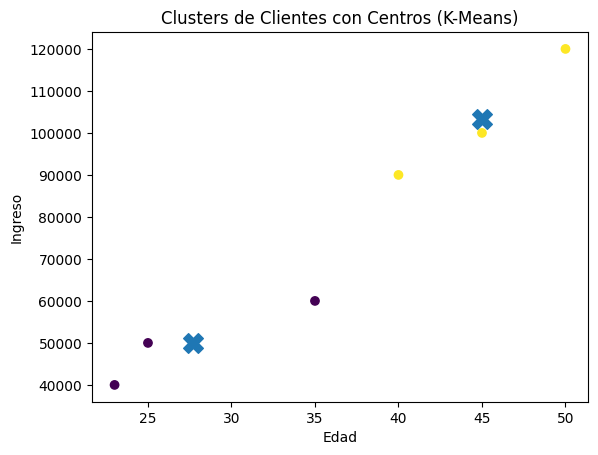

In [204]:
import matplotlib.pyplot as plt

# Convertir a pandas
df_plot = predicciones_k.select("edad", "ingreso", "prediction").toPandas()

# Obtener centros de los clusters
centros = modelo_k.clusterCenters()

# Separar coordenadas de centros
centros_x = [c[0] for c in centros]
centros_y = [c[1] for c in centros]

# Gráfico
plt.figure()

# Puntos (clientes)
plt.scatter(df_plot["edad"], df_plot["ingreso"], c=df_plot["prediction"])

# Centros (X grandes)
plt.scatter(centros_x, centros_y, marker='X', s=200)

plt.xlabel("Edad")
plt.ylabel("Ingreso")
plt.title("Clusters de Clientes con Centros (K-Means)")
plt.savefig("Clusters de Clientes con Centros (K-Means).png", dpi=300, bbox_inches="tight")
plt.show()

CONCLUSIÓN
El gráfico muestra la segmentación de clientes generada por el modelo K-Means, donde cada color representa un cluster distinto. Además, se incluyen los centros de cada cluster, representados con una "X", los cuales indican el punto promedio de cada grupo.

Se observa que los datos se agrupan en torno a estos centros, lo que confirma que el modelo ha identificado patrones claros en función de la edad y el ingreso. Esta segmentación permite comprender mejor los distintos perfiles de clientes y facilita la toma de decisiones en estrategias de marketing.